# Notebook 5 - Analisis de Negocio

Este cuaderno desarrolla la fase de Analisis de Negocio a partir de la base municipal segmentada generada en el `Notebook 4`.

A diferencia de los cuadernos anteriores, aqui el objetivo principal no es construir ni validar el dato, sino traducir los resultados tecnicos a una lectura aplicada para el sector asegurador. En este contexto, se interpretan los clusters, los indicadores de peligro climatico y las variables de vulnerabilidad territorial con el fin de identificar perfiles municipales relevantes, prioridades de actuacion y posibles implicaciones para tarificacion, prevencion y gestion de cartera.

La entrada principal del notebook es:

`DATA/PROCESSED/dataset_cv_municipios_segmentado.csv`

## 0. Configuracion inicial

En este bloque se cargan las librerias necesarias y se definen las rutas de trabajo. El notebook parte de la base municipal ya enriquecida y segmentada, por lo que no repite ni el proceso ETL ni el modelado previo.

Ademas, se preparan las rutas para posibles salidas de tablas, mapas y materiales de apoyo orientados a la interpretacion de negocio.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "DATA"
PROC = DATA / "PROCESSED"
EXT = DATA / "EXTERNAL"
OUT = ROOT / "output"
MAPS = OUT / "maps"
BUSINESS_OUT = OUT / "negocio"

SEGMENTED_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_segmentado.csv"
MUNICIPIOS_GEO_FILE = EXT / "municipios_cv.geojson"

MAPS.mkdir(parents=True, exist_ok=True)
BUSINESS_OUT.mkdir(parents=True, exist_ok=True)

print("Base municipal segmentada:", SEGMENTED_MUNICIPAL_FILE)
print("Existe:", SEGMENTED_MUNICIPAL_FILE.exists())
print("Geometria municipal disponible:", MUNICIPIOS_GEO_FILE.exists())
print("Directorio de salida negocio:", BUSINESS_OUT)

Base municipal segmentada: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_segmentado.csv
Existe: True
Geometria municipal disponible: True
Directorio de salida negocio: C:\Users\gonza\OneDrive\tfg\output\negocio


## 1. Objetivo de negocio y carga de la base segmentada

El objetivo de esta fase es interpretar la informacion municipal generada en los cuadernos anteriores desde una perspectiva aplicada al negocio asegurador. Para ello, se parte de los clusters, de los indicadores climaticos y de las variables territoriales ya construidas, y se analizan en terminos de exposicion, vulnerabilidad y prioridad operativa.

Dado que no se dispone de datos reales de siniestralidad, esta lectura no pretende sustituir un modelo actuarial ni una tarificacion real, sino ofrecer una aproximacion exploratoria que ayude a identificar perfiles municipales de interes, zonas de vigilancia prioritaria y posibles lineas de continuidad para una aseguradora.

In [2]:
df_seg = pd.read_csv(SEGMENTED_MUNICIPAL_FILE)

print("Shape:", df_seg.shape)
print("Municipios unicos:", df_seg["municipio"].nunique())
print("Clusters KMeans disponibles:", sorted(df_seg["cluster_kmeans"].dropna().unique().tolist()))
print("Clusters Agglomerative disponibles:", sorted(df_seg["cluster_agg"].dropna().unique().tolist()))

business_cols = [
    "municipio",
    "cluster_kmeans",
    "score_riesgo_preliminar",
    "score_peligro_climatico",
    "score_vulnerabilidad",
    "precip_p99",
    "dias_calor_intenso",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "altitud_m",
]

display(df_seg[business_cols].head())

Shape: (542, 44)
Municipios unicos: 542
Clusters KMeans disponibles: [0, 1, 2, 3, 4]
Clusters Agglomerative disponibles: [0, 1, 2, 3, 4]


,municipio,cluster_kmeans,score_riesgo_preliminar,score_peligro_climatico,score_vulnerabilidad,precip_p99,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
0,Ademuz,4,0.292826,0.201045,0.430498,18.368174,60,6.782720,10.12,26.80,27809.0,907.0
1,Ador,1,0.470979,0.552879,0.348130,37.833611,68,7.682318,126.84,20.42,31572.0,79.0
2,Agost,3,0.308108,0.276492,0.355532,18.520694,97,7.184352,78.39,20.27,30407.0,181.0
3,Agres,0,0.404786,0.418157,0.384731,31.017301,176,5.725050,24.10,24.80,31440.0,756.0
4,Agullent,0,0.397666,0.422197,0.360871,28.305807,200,5.912659,150.09,21.43,31085.0,556.0


## 2. Lectura de clusters en clave negocio

El primer paso del Analisis de Negocio consiste en traducir la segmentacion obtenida con `KMeans` a perfiles municipales interpretables desde una perspectiva aseguradora. Para ello, se comparan los clusters en terminos de peligro climatico, vulnerabilidad territorial, exposicion y contexto socioeconomico.

El objetivo no es asignar todavia decisiones tarifarias cerradas, sino identificar tipologias territoriales con implicaciones potenciales para prevencion, vigilancia, segmentacion comercial o priorizacion analitica.

In [3]:
cluster_business_summary = (
    df_seg.groupby("cluster_kmeans")
    .agg(
        municipios=("municipio", "count"),
        score_riesgo_preliminar=("score_riesgo_preliminar", "mean"),
        score_peligro_climatico=("score_peligro_climatico", "mean"),
        score_vulnerabilidad=("score_vulnerabilidad", "mean"),
        precip_p99=("precip_p99", "mean"),
        dias_calor_intenso=("dias_calor_intenso", "mean"),
        viento_p95=("viento_p95", "mean"),
        densidad_poblacion=("densidad_poblacion", "mean"),
        mayores_65_pct=("mayores_65_pct", "mean"),
        renta_media_hogar=("renta_media_hogar", "mean"),
        altitud_m=("altitud_m", "mean"),
    )
    .round(2)
    .sort_values("score_riesgo_preliminar", ascending=False)
)

display(cluster_business_summary)

,municipios,score_riesgo_preliminar,score_peligro_climatico,score_vulnerabilidad,precip_p99,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
cluster_kmeans,,,,,,,,,,,
0,104,0.45,0.50,0.37,32.51,183.56,6.43,184.85,23.82,32209.22,276.70
1,85,0.45,0.48,0.39,31.96,49.84,8.07,362.23,24.72,31269.49,244.48
3,104,0.39,0.38,0.41,20.70,185.02,6.93,231.72,25.07,29287.14,436.31
4,144,0.35,0.29,0.44,26.60,52.70,6.60,46.48,30.09,29990.33,698.65
2,105,0.33,0.34,0.32,23.93,88.09,7.17,2224.62,18.85,36631.25,123.29


In [4]:
cluster_business_labels = {
    0: "Peligro climatico alto y vulnerabilidad media",
    1: "Peligro alto con viento destacado",
    2: "Exposicion urbana densa y menor envejecimiento",
    3: "Calor y vulnerabilidad territorial elevada",
    4: "Interior envejecido y altitud alta",
}

df_seg["perfil_negocio_kmeans"] = df_seg["cluster_kmeans"].map(cluster_business_labels)

cluster_label_table = (
    df_seg[["cluster_kmeans", "perfil_negocio_kmeans"]]
    .drop_duplicates()
    .sort_values("cluster_kmeans")
)

display(cluster_label_table)

,cluster_kmeans,perfil_negocio_kmeans
3,0,Peligro climatico alto y vulnerabilidad media
1,1,Peligro alto con viento destacado
7,2,Exposicion urbana densa y menor envejecimiento
2,3,Calor y vulnerabilidad territorial elevada
0,4,Interior envejecido y altitud alta


In [5]:
municipios_representativos = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "score_riesgo_preliminar",
            "score_peligro_climatico",
            "score_vulnerabilidad",
        ]
    ]
    .sort_values(["cluster_kmeans", "score_riesgo_preliminar"], ascending=[True, False])
    .groupby("cluster_kmeans")
    .head(5)
)

display(municipios_representativos)

,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_preliminar,score_peligro_climatico,score_vulnerabilidad
220,Estubeny,0,Peligro climatico alto y vulnerabilidad media,0.531159,0.551178,0.501129
403,Sempere,0,Peligro climatico alto y vulnerabilidad media,0.519150,0.509625,0.533438
100,Benicolet,0,Peligro climatico alto y vulnerabilidad media,0.514058,0.550649,0.459171
436,Torrella,0,Peligro climatico alto y vulnerabilidad media,0.513079,0.551178,0.455931
418,Sumacàrcer,0,Peligro climatico alto y vulnerabilidad media,0.502856,0.550873,0.430831
507,l'Atzúbia,1,Peligro alto con viento destacado,0.525060,0.552879,0.483333
21,Alcalalí,1,Peligro alto con viento destacado,0.518785,0.497655,0.550479
388,Sanet y Negrals,1,Peligro alto con viento destacado,0.498870,0.497655,0.500693
289,Miramar,1,Peligro alto con viento destacado,0.498258,0.585852,0.366867
314,Oliva,1,Peligro alto con viento destacado,0.497778,0.585852,0.365667


La comparacion entre clusters permite construir una primera tipologia territorial util para negocio. En los resultados actuales, los clusters `0` y `1` destacan por combinar niveles elevados de peligro climatico, especialmente en precipitacion extrema y, en el caso del cluster `1`, tambien en viento intenso. El cluster `3` presenta una lectura diferente: menor precipitacion, pero una combinacion de calor intenso, menor renta y vulnerabilidad territorial relativamente alta.

Por otro lado, el cluster `2` concentra la mayor densidad de poblacion y una renta media superior, lo que sugiere un perfil de fuerte exposicion urbana aunque con menor envejecimiento medio. Finalmente, el cluster `4` agrupa municipios de mayor altitud, baja densidad y envejecimiento elevado, configurando un perfil de interior con vulnerabilidad demografica mas marcada.

Desde la perspectiva aseguradora, esta tipologia no equivale todavia a una politica de tarificacion, pero si resulta util para priorizar analisis posteriores, vigilancia territorial y posibles estrategias diferenciadas de prevencion o seguimiento de cartera.

## 3. Priorizacion municipal y ranking operativo

Una vez interpretados los clusters, el siguiente paso consiste en priorizar municipios desde una perspectiva operativa. Esta priorizacion no debe entenderse como una decision tarifaria automatica, sino como una herramienta exploratoria para identificar territorios que merecen mayor seguimiento, analisis adicional o atencion preventiva.

Para ello, se revisan tres lecturas complementarias: el score de riesgo preliminar, el score de peligro climatico y el score de vulnerabilidad territorial. De este modo, es posible distinguir municipios que destacan por la intensidad del peligro, por la fragilidad territorial o por la combinacion de ambas dimensiones.

In [6]:
ranking_cols = [
    "municipio",
    "cluster_kmeans",
    "perfil_negocio_kmeans",
    "score_riesgo_preliminar",
    "score_peligro_climatico",
    "score_vulnerabilidad",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
]

ranking_riesgo = df_seg[ranking_cols].sort_values("score_riesgo_preliminar", ascending=False).head(10)
ranking_peligro = df_seg[ranking_cols].sort_values("score_peligro_climatico", ascending=False).head(10)
ranking_vulnerabilidad = df_seg[ranking_cols].sort_values("score_vulnerabilidad", ascending=False).head(10)

print("Top 10 municipios por score de riesgo preliminar")
display(ranking_riesgo)
print("Top 10 municipios por score de peligro climatico")
display(ranking_peligro)
print("Top 10 municipios por score de vulnerabilidad")
display(ranking_vulnerabilidad)

Top 10 municipios por score de riesgo preliminar


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_preliminar,score_peligro_climatico,score_vulnerabilidad,densidad_poblacion,mayores_65_pct,renta_media_hogar
220,Estubeny,0,Peligro climatico alto y vulnerabilidad media,0.531159,0.551178,0.501129,17.13,34.55,27166.0
507,l'Atzúbia,1,Peligro alto con viento destacado,0.525060,0.552879,0.483333,40.12,35.94,30891.0
403,Sempere,0,Peligro climatico alto y vulnerabilidad media,0.519150,0.509625,0.533438,8.66,42.42,NaN
21,Alcalalí,1,Peligro alto con viento destacado,0.518785,0.497655,0.550479,99.19,40.85,27781.0
100,Benicolet,0,Peligro climatico alto y vulnerabilidad media,0.514058,0.550649,0.459171,53.82,31.98,29760.0
436,Torrella,0,Peligro climatico alto y vulnerabilidad media,0.513079,0.551178,0.455931,129.96,30.46,28694.0
253,Herbers,4,Interior envejecido y altitud alta,0.505309,0.459654,0.573791,2.51,42.65,26601.0
384,San Fulgencio,3,Calor y vulnerabilidad territorial elevada,0.503017,0.434950,0.605117,471.80,42.84,23694.0
418,Sumacàrcer,0,Peligro climatico alto y vulnerabilidad media,0.502856,0.550873,0.430831,50.41,28.99,30143.0
357,Quatretonda,0,Peligro climatico alto y vulnerabilidad media,0.502075,0.565828,0.406444,49.87,27.91,32049.0


Top 10 municipios por score de peligro climatico


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_preliminar,score_peligro_climatico,score_vulnerabilidad,densidad_poblacion,mayores_65_pct,renta_media_hogar
314,Oliva,1,Peligro alto con viento destacado,0.497778,0.585852,0.365667,445.35,21.98,31571.0
289,Miramar,1,Peligro alto con viento destacado,0.498258,0.585852,0.366867,1234.00,21.37,32129.0
343,Piles,1,Peligro alto con viento destacado,0.488546,0.585852,0.342586,806.46,18.21,31100.0
476,Xeraco,1,Peligro alto con viento destacado,0.483511,0.567162,0.358035,302.21,20.35,30562.0
238,Gandia,1,Peligro alto con viento destacado,0.478952,0.567162,0.346636,1361.23,18.88,32250.0
477,Xeresa,1,Peligro alto con viento destacado,0.461121,0.567162,0.302060,142.73,19.19,36055.0
250,Guardamar de la Safor,1,Peligro alto con viento destacado,0.448612,0.567162,0.270787,571.32,16.88,38260.0
205,Daimús,1,Peligro alto con viento destacado,0.485551,0.567162,0.363133,1121.36,22.68,33782.0
123,Benirredrà,1,Peligro alto con viento destacado,0.486080,0.567162,0.364457,4051.41,29.83,46164.0
357,Quatretonda,0,Peligro climatico alto y vulnerabilidad media,0.502075,0.565828,0.406444,49.87,27.91,32049.0


Top 10 municipios por score de vulnerabilidad


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_preliminar,score_peligro_climatico,score_vulnerabilidad,densidad_poblacion,mayores_65_pct,renta_media_hogar
290,Mislata,2,Exposicion urbana densa y menor envejecimiento,0.479923,0.376117,0.635632,23121.01,20.43,35060.0
92,Benetússer,2,Exposicion urbana densa y menor envejecimiento,0.492577,0.404112,0.625274,21451.10,19.36,32367.0
83,Benafigos,4,Interior envejecido y altitud alta,0.434474,0.314362,0.614640,3.40,45.45,24452.0
384,San Fulgencio,3,Calor y vulnerabilidad territorial elevada,0.503017,0.434950,0.605117,471.80,42.84,23694.0
304,Murla,4,Interior envejecido y altitud alta,0.485033,0.411563,0.595239,98.66,44.77,26321.0
423,Teresa de Cofrentes,3,Calor y vulnerabilidad territorial elevada,0.487662,0.417289,0.593221,5.60,43.20,24760.0
256,Hondón de los Frailes,3,Calor y vulnerabilidad territorial elevada,0.436479,0.333187,0.591417,106.33,40.67,22493.0
485,Zarra,3,Calor y vulnerabilidad territorial elevada,0.488517,0.422035,0.588241,7.52,42.26,24395.0
358,Quatretondeta,4,Interior envejecido y altitud alta,0.374787,0.233958,0.586031,7.78,39.53,21796.0
222,Famorca,4,Interior envejecido y altitud alta,0.389671,0.263999,0.578180,4.52,47.73,NaN


In [7]:
priority_order = ["Muy alta", "Alta", "Media", "Baja"]

p75_riesgo = df_seg["score_riesgo_preliminar"].quantile(0.75)
p75_peligro = df_seg["score_peligro_climatico"].quantile(0.75)
p75_vulnerabilidad = df_seg["score_vulnerabilidad"].quantile(0.75)
p50_riesgo = df_seg["score_riesgo_preliminar"].median()

condiciones = [
    (df_seg["score_peligro_climatico"] >= p75_peligro) & (df_seg["score_vulnerabilidad"] >= p75_vulnerabilidad),
    df_seg["score_riesgo_preliminar"] >= p75_riesgo,
    df_seg["score_riesgo_preliminar"] >= p50_riesgo,
]

etiquetas = ["Muy alta", "Alta", "Media"]

df_seg["prioridad_negocio"] = np.select(condiciones, etiquetas, default="Baja")
df_seg["prioridad_negocio"] = pd.Categorical(
    df_seg["prioridad_negocio"],
    categories=priority_order,
    ordered=True,
)

priority_summary = (
    df_seg.groupby("prioridad_negocio", observed=False)
    .agg(
        municipios=("municipio", "count"),
        riesgo_medio=("score_riesgo_preliminar", "mean"),
        peligro_medio=("score_peligro_climatico", "mean"),
        vulnerabilidad_media=("score_vulnerabilidad", "mean"),
    )
    .round(3)
    .reindex(priority_order)
)

display(priority_summary)

,municipios,riesgo_medio,peligro_medio,vulnerabilidad_media
prioridad_negocio,,,,
Muy alta,19,0.499,0.515,0.474
Alta,117,0.471,0.514,0.406
Media,135,0.417,0.426,0.403
Baja,271,0.334,0.309,0.372


In [8]:
municipios_prioritarios = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            "score_riesgo_preliminar",
            "score_peligro_climatico",
            "score_vulnerabilidad",
        ]
    ]
    .query("prioridad_negocio in ['Muy alta', 'Alta']")
    .sort_values(["prioridad_negocio", "score_riesgo_preliminar"], ascending=[True, False])
)

display(municipios_prioritarios.head(20))

,municipio,cluster_kmeans,perfil_negocio_kmeans,prioridad_negocio,score_riesgo_preliminar,score_peligro_climatico,score_vulnerabilidad
220,Estubeny,0,Peligro climatico alto y vulnerabilidad media,Muy alta,0.531159,0.551178,0.501129
507,l'Atzúbia,1,Peligro alto con viento destacado,Muy alta,0.525060,0.552879,0.483333
403,Sempere,0,Peligro climatico alto y vulnerabilidad media,Muy alta,0.519150,0.509625,0.533438
21,Alcalalí,1,Peligro alto con viento destacado,Muy alta,0.518785,0.497655,0.550479
100,Benicolet,0,Peligro climatico alto y vulnerabilidad media,Muy alta,0.514058,0.550649,0.459171
436,Torrella,0,Peligro climatico alto y vulnerabilidad media,Muy alta,0.513079,0.551178,0.455931
388,Sanet y Negrals,1,Peligro alto con viento destacado,Muy alta,0.498870,0.497655,0.500693
154,Canet lo Roig,1,Peligro alto con viento destacado,Muy alta,0.495765,0.504904,0.482056
98,Beniatjar,0,Peligro climatico alto y vulnerabilidad media,Muy alta,0.494393,0.513605,0.465577
387,San Rafael del Río,1,Peligro alto con viento destacado,Muy alta,0.493242,0.520947,0.451686


La priorizacion obtenida permite pasar de una lectura descriptiva de clusters a una primera propuesta de seguimiento operativo. Los municipios clasificados con prioridad `Muy alta` combinan niveles elevados de peligro climatico y vulnerabilidad, por lo que constituirian candidatos naturales para una vigilancia reforzada o para analisis adicionales mas detallados.

Por su parte, las prioridades `Alta` y `Media` recogen perfiles donde una de las dimensiones destaca con fuerza, aunque la combinacion global sea menos extrema. Esta distincion resulta util porque evita tratar de forma identica municipios con riesgos de naturaleza distinta: algunos destacan por exposicion urbana, otros por envejecimiento y altitud, y otros por precipitacion extrema, calor o viento.

Desde la perspectiva aseguradora, esta tipologia puede servir como base para ordenar territorios, focalizar estudios complementarios y plantear estrategias diferenciadas de prevencion, seguimiento o revision analitica de cartera.

## 4. Representacion espacial de prioridades y perfiles de negocio

La lectura de negocio gana fuerza cuando los perfiles y prioridades identificados se trasladan al espacio geogr?fico. En este bloque se representan los clusters principales y la prioridad operativa para comprobar si existen concentraciones territoriales, continuidades espaciales o contrastes relevantes entre zonas.

El objetivo no es producir una zonificacion definitiva del riesgo asegurador, sino aportar una evidencia visual que ayude a interpretar mejor donde se concentran los perfiles municipales mas sensibles desde la perspectiva del negocio.

In [9]:
gdf_business = gpd.read_file(MUNICIPIOS_GEO_FILE).merge(
    df_seg[
        [
            "municipio",
            "CODNUT2",
            "CODNUT3",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            "score_riesgo_preliminar",
            "score_peligro_climatico",
            "score_vulnerabilidad",
        ]
    ],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

print("Municipios en geometria:", len(gdf_business))
print("Municipios con prioridad asignada:", gdf_business["prioridad_negocio"].notna().sum())
display(gdf_business[["municipio", "cluster_kmeans", "prioridad_negocio"]].head())

Municipios en geometria: 542
Municipios con prioridad asignada: 542


,municipio,cluster_kmeans,prioridad_negocio
0,l'Atzúbia,1,Muy alta
1,Agost,3,Baja
2,Agres,0,Media
3,Aigües,2,Baja
4,Albatera,3,Baja


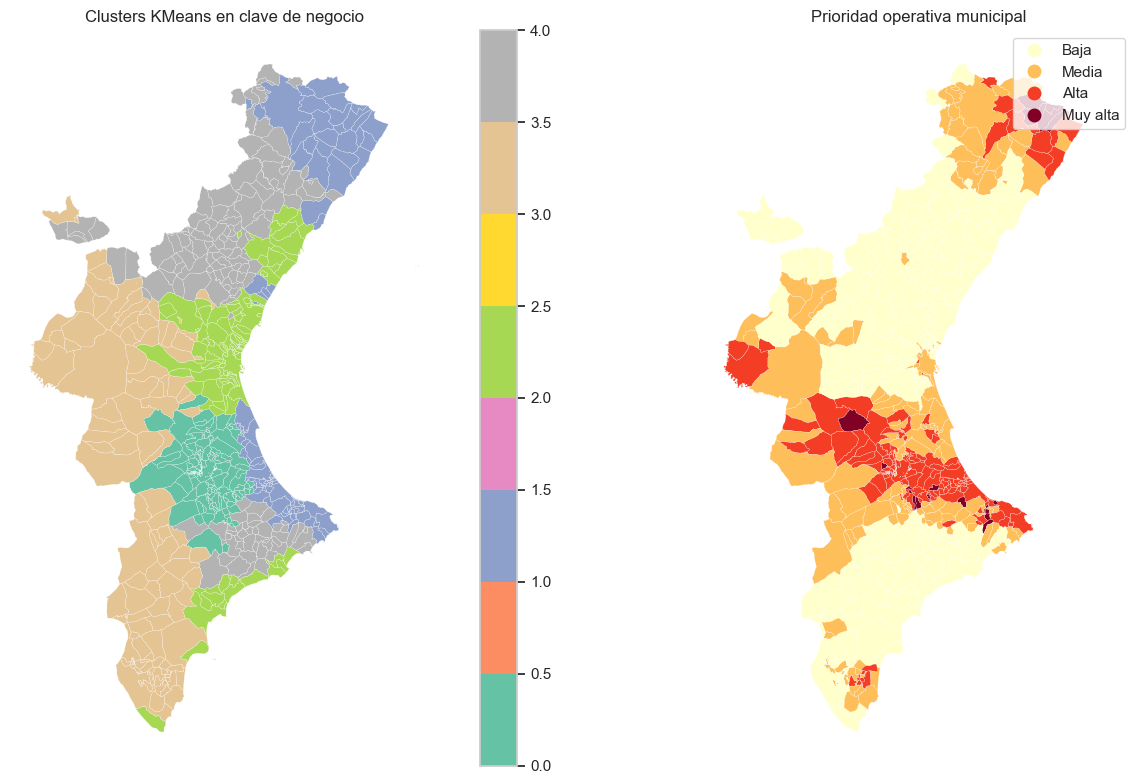

In [10]:
map_priority_order = ["Baja", "Media", "Alta", "Muy alta"]
gdf_business["prioridad_negocio"] = pd.Categorical(
    gdf_business["prioridad_negocio"],
    categories=map_priority_order,
    ordered=True,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

gdf_business.plot(
    column="cluster_kmeans",
    cmap="Set2",
    legend=True,
    ax=axes[0],
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)
axes[0].set_title("Clusters KMeans en clave de negocio")
axes[0].axis("off")

gdf_business.plot(
    column="prioridad_negocio",
    cmap="YlOrRd",
    legend=True,
    ax=axes[1],
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)
axes[1].set_title("Prioridad operativa municipal")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
priority_by_cluster = (
    df_seg.groupby(["cluster_kmeans", "prioridad_negocio"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=priority_order, fill_value=0)
)

display(priority_by_cluster)

prioridad_negocio,Muy alta,Alta,Media,Baja
cluster_kmeans,,,,
0,8,57,32,7
1,11,39,26,9
2,0,3,13,89
3,0,15,38,51
4,0,3,26,115


La representacion espacial permite comprobar que las prioridades no se distribuyen de forma aleatoria, sino que responden a combinaciones territoriales concretas de clima, vulnerabilidad y exposicion. Esta lectura resulta especialmente util para pasar de una lista de municipios a una interpretacion espacial mas cercana a decisiones de vigilancia, seguimiento o segmentacion de cartera.

Ademas, el cruce entre clusters y prioridad operativa ayuda a entender que una misma prioridad puede responder a l?gicas distintas: en algunos casos pesa mas la peligrosidad climatica, en otros la vulnerabilidad demografica o la exposicion urbana. Esta distincion es relevante porque sugiere que las posibles respuestas de negocio tampoco deberian ser identicas en todos los territorios.

## 5. Implicaciones para una aseguradora

A partir de los perfiles municipales, de los rankings y de la prioridad operativa construida en los bloques anteriores, es posible extraer una primera lectura orientada a negocio. Esta lectura no sustituye un modelo actuarial ni una politica tarifaria real, pero si permite plantear usos potenciales del analisis para prevencion, seguimiento territorial y segmentacion de cartera.

El interes principal de este bloque reside en traducir los resultados tecnicos a preguntas mas proximas a la decision: que territorios merecen mayor vigilancia, donde pueden concentrarse riesgos emergentes, y que perfiles municipales podrian justificar estrategias diferenciales de seguimiento o profundizacion analitica.

In [12]:
priority_business_table = (
    df_seg.groupby("prioridad_negocio", observed=False)
    .agg(
        municipios=("municipio", "count"),
        poblacion_total=("poblacion_total", "sum"),
        riesgo_medio=("score_riesgo_preliminar", "mean"),
        peligro_medio=("score_peligro_climatico", "mean"),
        vulnerabilidad_media=("score_vulnerabilidad", "mean"),
    )
    .round(3)
    .reindex(priority_order)
)

display(priority_business_table)

,municipios,poblacion_total,riesgo_medio,peligro_medio,vulnerabilidad_media
prioridad_negocio,,,,,
Muy alta,19,14259.0,0.499,0.515,0.474
Alta,117,570583.0,0.471,0.514,0.406
Media,135,1775877.0,0.417,0.426,0.403
Baja,271,3055124.0,0.334,0.309,0.372


Desde una perspectiva aseguradora, los resultados sugieren al menos cuatro lineas de utilidad potencial:

1. **Vigilancia territorial reforzada**: los municipios con prioridad `Muy alta` o `Alta` pueden considerarse candidatos para seguimiento especifico, revision periodica o analisis territorial adicional, especialmente cuando combinan peligro climatico elevado y vulnerabilidad social.

2. **Prevencion y comunicacion segmentada**: los perfiles identificados permiten imaginar acciones preventivas diferenciadas. Por ejemplo, los clusters mas ligados a precipitacion extrema o viento pueden asociarse a recomendaciones de proteccion material y continuidad operativa, mientras que los perfiles mas envejecidos o vulnerables pueden requerir un enfoque mas centrado en respuesta y acompanamiento.

3. **Segmentacion territorial de cartera**: aunque el trabajo no dispone de siniestros reales ni de primas, la tipologia municipal construida puede servir como capa auxiliar para segmentar territorios y priorizar donde conviene profundizar con informacion interna de exposicion, polizas o historicidad de eventos.

4. **Priorizacion de futuras integraciones de datos**: los municipios destacados por riesgo, peligro o vulnerabilidad ofrecen una base razonable para decidir donde seria mas valioso incorporar nuevas fuentes, como siniestros reales, Catastro o informacion mas fina sobre parque edificado.

In [13]:
casos_tipo_negocio = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            "score_riesgo_preliminar",
            "score_peligro_climatico",
            "score_vulnerabilidad",
            "densidad_poblacion",
            "mayores_65_pct",
            "renta_media_hogar",
        ]
    ]
    .sort_values(["prioridad_negocio", "score_riesgo_preliminar"], ascending=[True, False])
    .groupby("perfil_negocio_kmeans")
    .head(2)
)

display(casos_tipo_negocio)

,municipio,cluster_kmeans,perfil_negocio_kmeans,prioridad_negocio,score_riesgo_preliminar,score_peligro_climatico,score_vulnerabilidad,densidad_poblacion,mayores_65_pct,renta_media_hogar
220,Estubeny,0,Peligro climatico alto y vulnerabilidad media,Muy alta,0.531159,0.551178,0.501129,17.13,34.55,27166.0
507,l'Atzúbia,1,Peligro alto con viento destacado,Muy alta,0.525060,0.552879,0.483333,40.12,35.94,30891.0
403,Sempere,0,Peligro climatico alto y vulnerabilidad media,Muy alta,0.519150,0.509625,0.533438,8.66,42.42,NaN
21,Alcalalí,1,Peligro alto con viento destacado,Muy alta,0.518785,0.497655,0.550479,99.19,40.85,27781.0
253,Herbers,4,Interior envejecido y altitud alta,Alta,0.505309,0.459654,0.573791,2.51,42.65,26601.0
384,San Fulgencio,3,Calor y vulnerabilidad territorial elevada,Alta,0.503017,0.434950,0.605117,471.80,42.84,23694.0
456,Venta del Moro,3,Calor y vulnerabilidad territorial elevada,Alta,0.496634,0.463490,0.546350,4.20,35.93,22952.0
92,Benetússer,2,Exposicion urbana densa y menor envejecimiento,Alta,0.492577,0.404112,0.625274,21451.10,19.36,32367.0
304,Murla,4,Interior envejecido y altitud alta,Alta,0.485033,0.411563,0.595239,98.66,44.77,26321.0
290,Mislata,2,Exposicion urbana densa y menor envejecimiento,Alta,0.479923,0.376117,0.635632,23121.01,20.43,35060.0


La tabla de casos tipo ayuda a aterrizar el analisis en ejemplos concretos. En lugar de quedarse en clusters abstractos, permite visualizar municipios que representan perfiles distintos de negocio: territorios con mayor peligro climatico, municipios expuestos por densidad, zonas interiores envejecidas o combinaciones de calor y vulnerabilidad.

Esta lectura no basta por si sola para definir acciones comerciales o tarifarias, pero si aporta una base argumental util para justificar donde podria concentrarse primero un esfuerzo adicional de analisis, prevencion o enriquecimiento de informacion interna.

## 6. Limitaciones y continuidad del analisis de negocio

Aunque el analisis desarrollado en este cuaderno permite traducir los resultados tecnicos a una lectura aplicada para una aseguradora, conviene subrayar varias limitaciones. En primer lugar, el trabajo no dispone de datos reales de siniestralidad, primas, exposicion asegurada ni composicion efectiva de cartera, por lo que las conclusiones no pueden interpretarse como una politica tarifaria ni como una estimacion real de impacto economico.

En segundo lugar, la resolucion espacial del bloque climatico sigue condicionada por la malla de `ERA5-Land`, lo que implica que varios municipios comparten una misma representacion climatica. Esto reduce el detalle territorial fino y aconseja interpretar los resultados como una aproximacion municipal robusta, pero no como una medicion exacta del riesgo local.

En tercer lugar, la vulnerabilidad territorial utilizada en el proyecto se apoya en variables abiertas de contexto, como densidad, envejecimiento o renta, que aportan valor interpretativo pero no sustituyen informacion aseguradora interna sobre tipos de poliza, capitales expuestos, historial de siniestros o comportamiento real de la cartera.

Precisamente por ello, la continuidad natural del trabajo consistiria en enriquecer esta base con informacion adicional. Entre las ampliaciones mas valiosas se encuentran la incorporacion de siniestros reales, la integracion de Catastro u otras capas de exposicion fisica, una validacion climatica mas amplia con `AEMET` y, en una fase mas avanzada, el uso de fuentes o modelos climaticos de mayor resolucion. En ese escenario, la tipologia municipal construida aqui podria servir como capa previa de segmentacion sobre la que apoyar analisis aseguradores mas proximos a la decision real.

## 7. Conclusiones del analisis de negocio

El Analisis de Negocio realizado en este cuaderno permite transformar la base municipal segmentada en una lectura aplicada del territorio desde la perspectiva aseguradora. A partir de los clusters, de los indicadores climaticos y de la prioridad operativa construida, se han identificado perfiles municipales diferenciados que combinan de forma distinta peligro climatico, exposicion y vulnerabilidad.

El principal valor de esta fase no reside en ofrecer una respuesta actuarial cerrada, sino en demostrar que la informacion abierta tratada en las fases anteriores puede organizarse de forma util para priorizar territorios, orientar vigilancia, plantear estrategias preventivas y decidir donde tendria mas sentido profundizar con informacion interna de negocio.

En conjunto, el trabajo deja preparada una base metodologica coherente para una continuidad futura mas cercana a uso asegurador real. Incluso sin datos internos de siniestros, el proyecto ya permite pasar de una lectura puramente climatica a una interpretacion territorial estructurada, conectando Ingenieria del Dato, Analisis del Dato y Analisis de Negocio dentro de una misma narrativa de TFG.